In [1]:
import pandas as pd, numpy as np, seaborn as sns, matplotlib.pyplot as plt
import glob, os, sys

from data.movie import Frames, Audio #, People Measures
from data.spikes import Rates # LFP, BOLD
from data.behavior import Gaze, Suspense # Suspense, Valence, Arousal

from tqdm import tqdm


### helpers

In [26]:
rescale_t = 1

min_max = lambda x: (x - x.min()) / (x.max() - x.min())

def remove_nans_inf_outliers(T_by_N):

    clean_T_by_N = T_by_N.copy()
    clean_T_by_N = clean_T_by_N[:, np.isfinite(T_by_N).all(axis=0)] # remove nans/infs
    clean_T_by_N = clean_T_by_N[:, clean_T_by_N.mean(axis=0) > 0.1] # remove low FR neurs
    
    print(f'dropping {T_by_N.shape[1] - clean_T_by_N.shape[1]} neurs.\nRetaining {clean_T_by_N.shape[1]} neurs.')

    return clean_T_by_N

def get_region_mtx(df, region):

    region_cols = [col for col in df.columns if region in col]
    region_mtx = df[region_cols].copy().values
    clean_mtx = remove_nans_inf_outliers(region_mtx)

    return clean_mtx # T by N



## 1. suspense

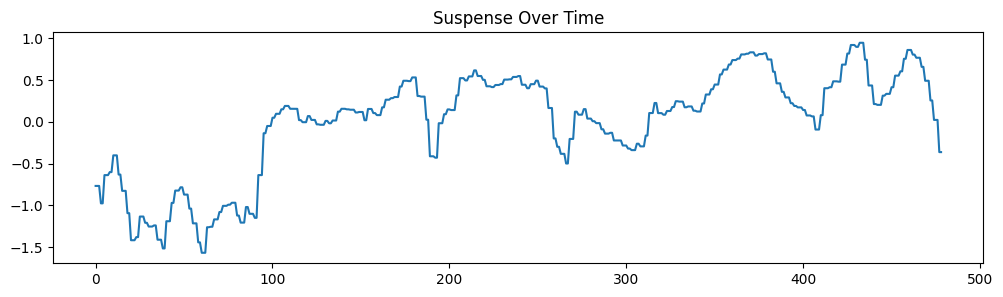

In [27]:
suspense = Suspense().rescale(rescale_t)
avg_suspense = suspense.mean(axis=1)

plt.figure(figsize=(12, 3))
plt.title('Suspense Over Time')
plt.plot(avg_suspense)
plt.show()

## 2. audio

(479, 6)


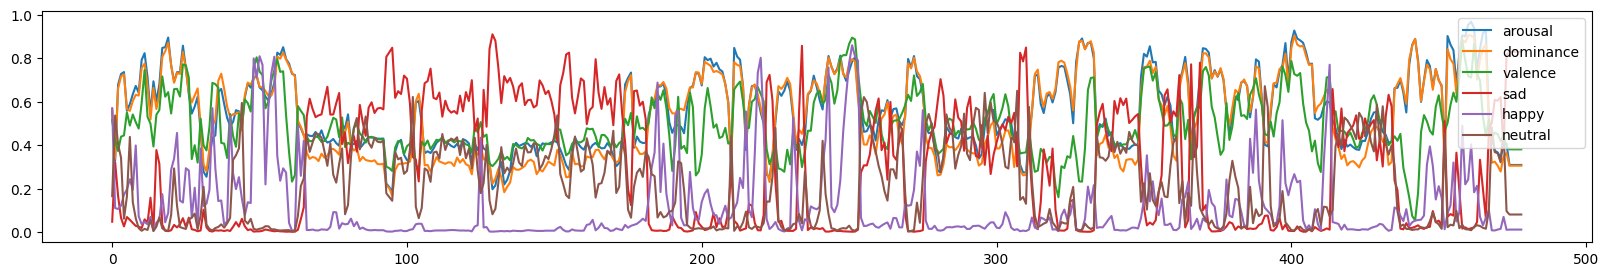

In [28]:
audio = Audio()
audio_metrics = [
    audio.vocals.arousal,
    audio.vocals.dominance,
    audio.vocals.valence,
    # audio.vocals.angry, #
    audio.vocals.sad,
    audio.vocals.happy,
    # audio.vocals.surprise,
    audio.vocals.neutral,
]

# apply rescaling and stack into a matrix
rescaled_metrics = [data.rescale(1) for data in audio_metrics]
aud_mtx = np.stack(rescaled_metrics, axis=1)  # shape: (n_timepoints, n_features)
print(aud_mtx.shape)

df_audio = pd.DataFrame(aud_mtx, columns=[
    'arousal', 'dominance', 'valence',
    # 'angry',
    'sad', 'happy',
    # 'surprise',
    'neutral'
])

plt.figure(figsize=(20, 3))
for col in df_audio.columns:
    plt.plot(df_audio[col], label=col)
plt.legend()
plt.show()

### combine & plot audio features

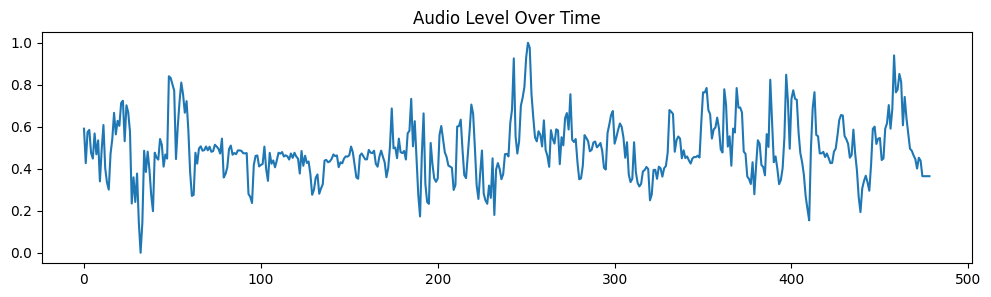

In [29]:
aud_level = aud_mtx.sum(axis=1)
plt.figure(figsize=(12, 3))
plt.plot(min_max(aud_level))
plt.title('Audio Level Over Time')
plt.show()

## 3. visual

In [30]:
# load visual metrics (e.g., pix diff, number of faces, etc.)
# rescale to 1, such that i have vis_mtx which has shape = (N, T)

### combine & plot visual features

In [31]:
##

## Forming conditions

In [32]:
cond_names = {
    0: 'Low Sensory, Low Suspense',
    1: 'Low Sensory, High Suspense',
    2: 'High Sensory, Low Suspense',
    3: 'High Sensory, High Suspense'
}

def get_conds(df_audio, avg_suspense, sen_thresh=50, sus_thresh=50):
    
    # Sensory conditions based on audio features
    sensory_output = df_audio.prod(axis=1)  # shape: (n_timepoints,)

    sensory_cond = np.array((sensory_output > np.percentile(sensory_output, sen_thresh)))
    suspense_cond = np.array((avg_suspense > np.percentile(avg_suspense, sus_thresh)))

    sen_sus_conds = sensory_cond * 2 + suspense_cond # resulting in 0,1,2,3

    return sen_sus_conds

def get_conds(avg_sensory, avg_suspense, sen_thresh=50, sus_thresh=50):

    sensory_cond = np.array((avg_sensory > np.percentile(avg_sensory, sen_thresh)))
    suspense_cond = np.array((avg_suspense > np.percentile(avg_suspense, sus_thresh)))

    sen_sus_conds = sensory_cond * 2 + suspense_cond # resulting in 0,1,2,3

    return sen_sus_conds


In [33]:
# setup
avg_sensory = aud_level.copy() 
sen_sus_conds = get_conds(avg_sensory, avg_suspense, 50, 50)

# checking
unique, counts = np.unique(sen_sus_conds, return_counts=True)
cond_counts = dict(zip(unique, counts))
for cond in range(4):
    print(f'{cond_names[cond]} pts: {cond_counts[cond]}')


Low Sensory, Low Suspense pts: 127
Low Sensory, High Suspense pts: 113
High Sensory, Low Suspense pts: 114
High Sensory, High Suspense pts: 125


## FRs

In [34]:
df_FRs = Rates().rescale(rescale_t)
regions = ['ACC', 'amygdala', 'hippocampus', 'vmPFC', 'preSMA']
df_FRs

/home/nuttidalab/Documents/movie_analysis/data/spikes/rate.py:51: RuntimeWarning: divide by zero encountered in divide
  enc_rate_normed = (enc_rates - base_mean) / base_sd
/home/nuttidalab/Documents/movie_analysis/data/spikes/rate.py:51: RuntimeWarning: invalid value encountered in divide
  enc_rate_normed = (enc_rates - base_mean) / base_sd


,Left_ACC_P58CS_R1_1_1_994_6,Right_ACC_P58CS_R1_35_2_2425_5,Right_ACC_P58CS_R1_35_1_2195_5,Right_ACC_P58CS_R1_34_4_3301_5,Right_ACC_P58CS_R1_34_3_3299_5,Right_ACC_P58CS_R1_34_2_3239_5,Right_ACC_P58CS_R1_34_1_3232_5,Right_ACC_P58CS_R1_36_1_712_5,Right_ACC_P58CS_R1_36_2_962_5,Right_ACC_P58CS_R1_38_1_1473_5,...,Right_amygdala_P62CS_R1_28_1_6059_3,Right_amygdala_P62CS_R1_27_3_8498_3,Right_preSMA_P62CS_R1_22_3_2598_7,Right_preSMA_P62CS_R1_22_2_2532_7,Right_preSMA_P62CS_R1_22_1_2407_7,Right_preSMA_P62CS_R1_18_3_3847_7,Right_preSMA_P62CS_R1_18_2_3846_7,Right_preSMA_P62CS_R1_18_1_3830_7,Right_vmPFC_P62CS_R1_7_1_791_9,Right_vmPFC_P62CS_R1_5_1_1374_9
0.0,-0.338208,-0.374166,-0.107521,-0.923221,0.257964,-0.088289,-0.390434,2.244494,0.302122,0.393852,...,-0.171499,NaN,-0.188950,-0.485326,-0.171499,0.024249,1.280264,-0.589448,-0.457766,-0.062201
1.0,-0.338208,-0.374166,-0.107521,-1.000089,-0.574717,0.340222,-0.390434,2.887818,1.296439,1.549817,...,-0.171499,NaN,-0.150624,-0.485259,-0.171499,0.050365,0.209403,-0.589448,-0.005204,-0.294342
2.0,-0.338208,-0.374166,-0.107521,-0.134325,-0.131042,0.593294,-0.390312,6.613831,1.113987,0.294318,...,-0.171499,NaN,0.703743,-0.333462,-0.171499,-0.211629,0.858131,-0.589448,-0.225080,-0.296496
3.0,-0.338208,-0.374166,-0.107521,2.040038,0.232627,0.389511,0.292734,2.013020,1.050507,1.038302,...,-0.171499,NaN,-0.325370,-0.220164,-0.171499,0.095727,0.476378,-0.589448,0.028679,-0.220789
4.0,-0.338208,-0.374166,-0.107521,0.512235,-0.722726,-0.457154,0.516420,0.090433,0.260862,0.102534,...,-0.171499,NaN,-0.356894,-0.485191,-0.171499,-0.159577,0.302962,-0.589448,0.120814,0.327731
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
474.0,-0.338208,-0.374041,-0.107521,0.031678,-0.117056,0.119806,0.087395,-0.107521,-0.257123,-0.462101,...,-0.171499,NaN,0.281662,-0.369646,-0.171499,-0.133381,0.812446,0.008545,0.228790,0.044538
475.0,-0.338208,0.037009,0.076115,-0.292360,-0.133325,0.286691,-0.116771,-0.107521,0.219609,0.014690,...,-0.171499,NaN,0.371900,-0.133950,-0.171499,-0.256176,-0.409717,0.260416,0.229811,0.703491
476.0,-0.338208,1.043194,2.844863,-0.093900,-0.574784,0.245846,-0.386153,-0.107521,0.709171,-0.455701,...,-0.171499,NaN,-0.396999,-0.151995,-0.162363,0.368297,-0.000177,-0.264589,0.352840,0.230458
477.0,-0.338208,-0.015422,2.233755,0.705968,-0.117106,0.836228,0.455036,0.030206,0.268840,-0.489116,...,-0.171499,NaN,0.089519,0.135114,1.234392,-0.226664,-0.224824,0.067774,0.028679,0.538756


dropping 732 neurs.
Retaining 725 neurs.
(725, 479)


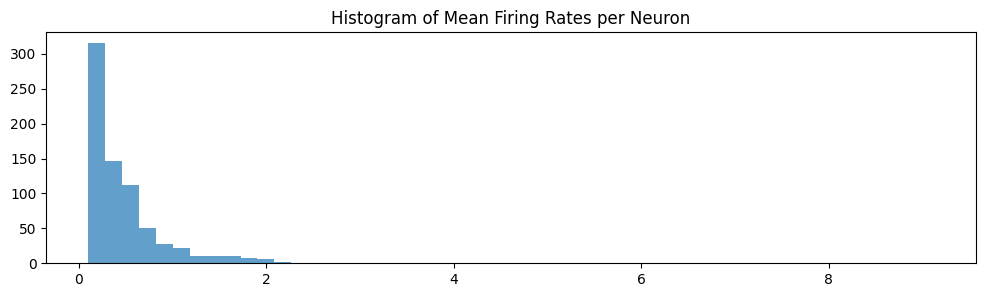

In [35]:
# store as arr
T_by_N = remove_nans_inf_outliers(df_FRs.values)
N_by_T = T_by_N.T
print(N_by_T.shape)

plt.figure(figsize=(12, 3))
plt.hist(T_by_N.mean(axis=0), bins=50, alpha=0.7)
plt.title('Histogram of Mean Firing Rates per Neuron')
plt.show()


dropping 239 neurs.
Retaining 243 neurs.
dropping 239 neurs.
Retaining 243 neurs.
dropping 239 neurs.
Retaining 243 neurs.
dropping 239 neurs.
Retaining 243 neurs.


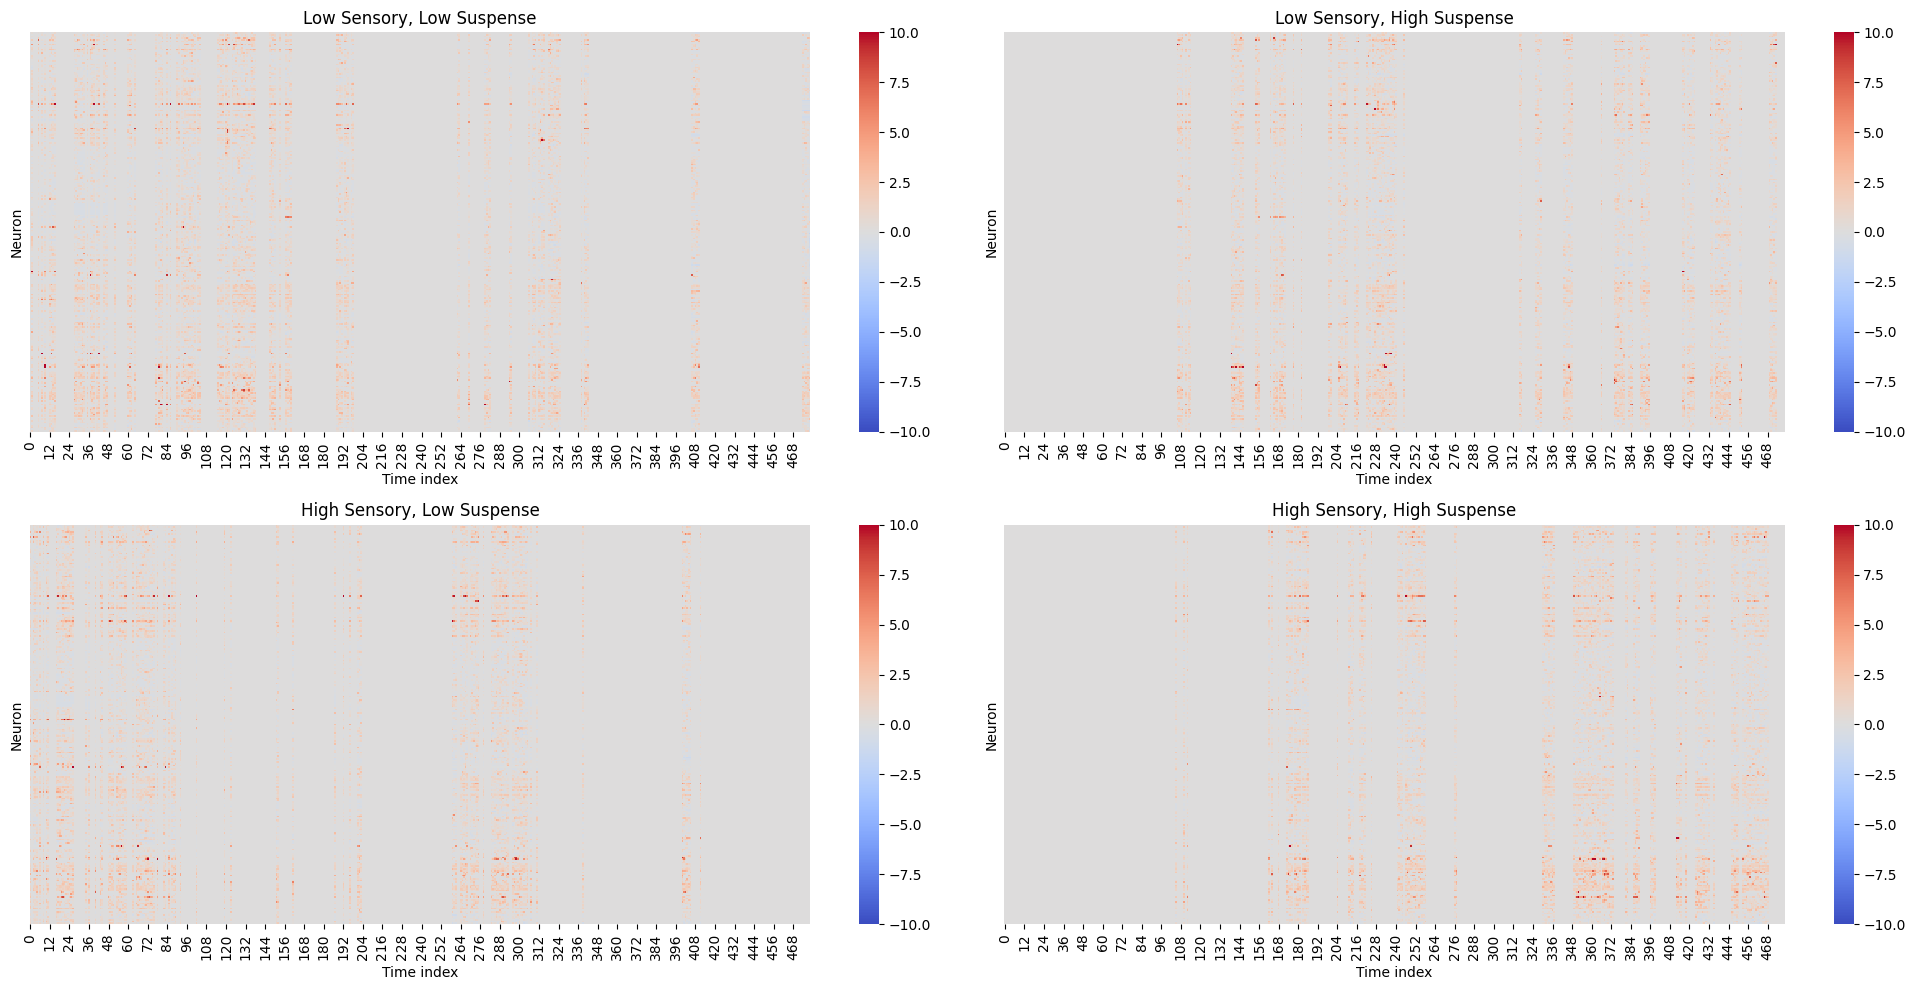

In [36]:
# plot
region = 'amygdala'

fig, axs = plt.subplots(2, 2, figsize=(20, 10))
axs, ax = axs.flatten(), 0
FR_plt_rng = 10

for cond in range(4):
    
    if region == '': cond_N_by_T = N_by_T.copy() # full mtx
    else:            cond_N_by_T = get_region_mtx(df_FRs, region).copy().T # region mtx

    # nullify non-condition times
    cond_N_by_T[:, sen_sus_conds != cond] = 0
    
    assert cond_N_by_T.shape[1] == len(suspense), "mtx improperly transposed"

    sns.heatmap(cond_N_by_T, cmap='coolwarm', ax=axs[ax], vmin=-FR_plt_rng, vmax=FR_plt_rng)
    axs[ax].set(title=f'{cond_names[cond]}', xlabel='Time index', ylabel='Neuron', yticks=[])
    ax += 1

plt.tight_layout()
plt.show()

### GLMs

In [37]:
# setup
from sklearn.linear_model import Ridge

T_by_feats = aud_mtx
assert T_by_N.shape[0] == T_by_feats.shape[0], f'{T_by_N.shape} != {T_by_feats.shape}'


In [38]:
# function
def get_GLM(X, Y):

    model = Ridge(alpha=1.0)
    coefs = []
    for n in range(Y.shape[1]):
        model.fit(X, Y[:, n])
        coefs.append(model.coef_)  # shape: (n_features,)

    coefs = np.array(coefs).T  # shape: (n_feats, n_neurs)
    
    return coefs

dropping 239 neurs.
Retaining 243 neurs.
dropping 239 neurs.
Retaining 243 neurs.
dropping 239 neurs.
Retaining 243 neurs.
dropping 239 neurs.
Retaining 243 neurs.


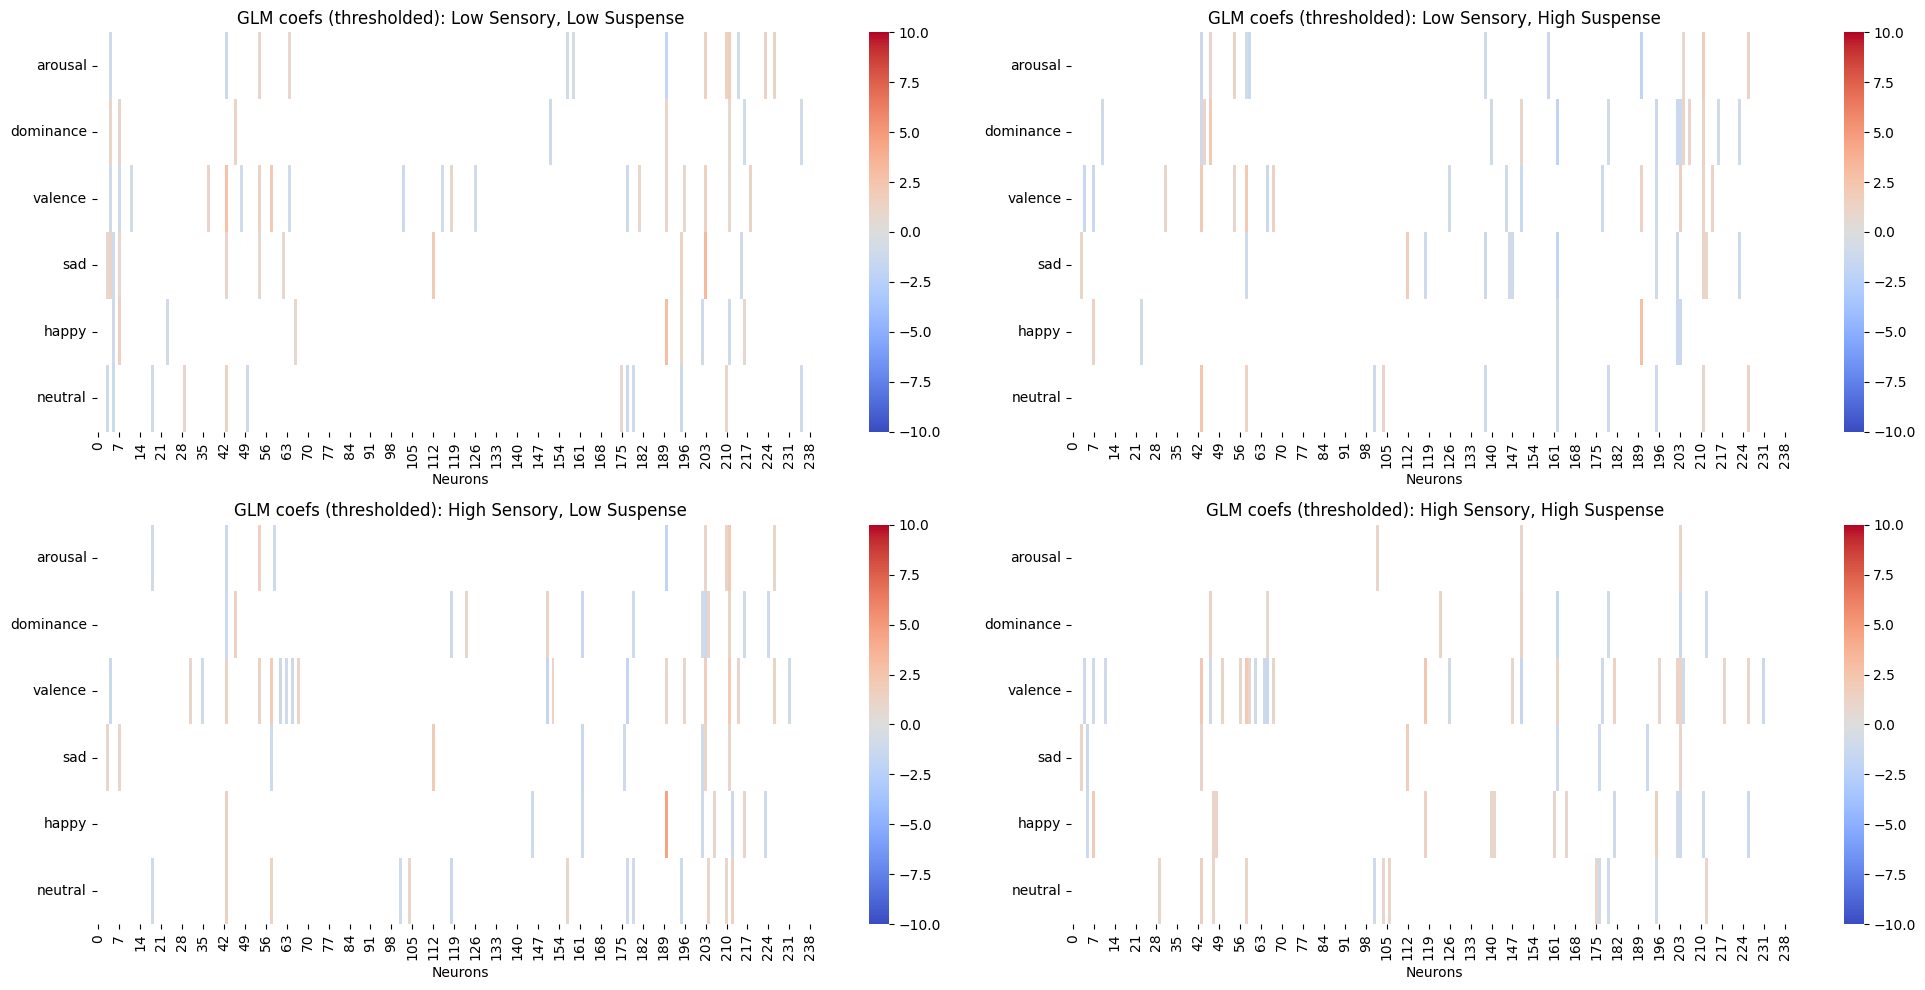

In [39]:
# plot
region = 'amygdala'

fig, axs = plt.subplots(2, 2, figsize=(20, 10))
axs, ax = axs.flatten(), 0
plt_rng = 10

for cond in range(4):

    if region == '': cond_T_by_N = T_by_N.copy() # full mtx
    else:            cond_T_by_N = get_region_mtx(df_FRs, region).copy() # region mtx

    # index condition times
    cond_T_by_N = cond_T_by_N[sen_sus_conds != cond, :].copy()
    cond_T_by_feats = T_by_feats[sen_sus_conds != cond, :].copy()

    glm_coefs = get_GLM(cond_T_by_feats, cond_T_by_N)
    
    mask = np.abs(glm_coefs) > np.percentile(np.abs(glm_coefs), 95)
    sns.heatmap(glm_coefs, mask=~mask, cmap='coolwarm', ax=axs[ax], cbar=True, vmax=plt_rng, vmin=-plt_rng)
    # sns.clustermap(glm_coefs, cmap='coolwarm', col_cluster=True, row_cluster=False)
    axs[ax].set(title=f'GLM coefs (thresholded): {cond_names[cond]}', xlabel='Neurons')
    axs[ax].set_yticklabels(df_audio.columns, rotation=0)
    ax += 1

plt.tight_layout()
plt.show()

### time-time corr by condition

dropping 76 neurs.
Retaining 99 neurs.
dropping 76 neurs.
Retaining 99 neurs.
dropping 76 neurs.
Retaining 99 neurs.
dropping 76 neurs.
Retaining 99 neurs.


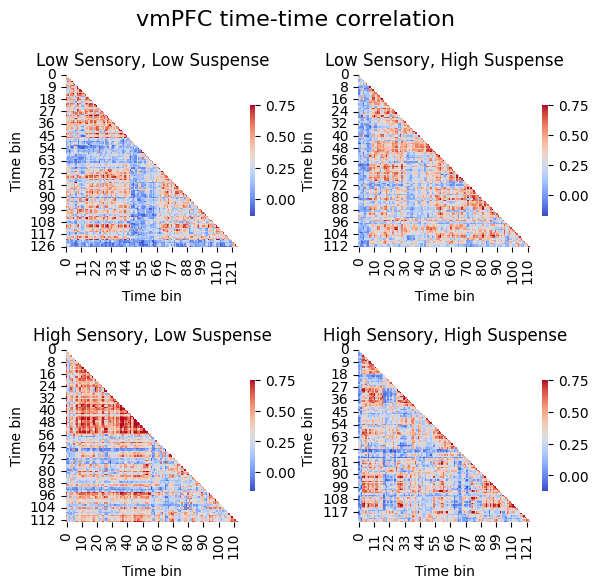

In [63]:
# plot
sen_sus_conds = get_conds(avg_sensory, avg_suspense)
fig, axs = plt.subplots(2, 2, figsize=(6, 6))
axs, ax = axs.flatten(), 0
plt_rng = 10
region = 'vmPFC' # '' for full mtx

for cond in range(4):

    if region == '': cond_T_by_N = T_by_N.copy() # full mtx
    else:            cond_T_by_N = get_region_mtx(df_FRs, region).copy() # region mtx

    # index condition times
    cond_T_by_N = cond_T_by_N[sen_sus_conds == cond, :].copy()

    tt_corr = np.corrcoef(cond_T_by_N)
    mask = np.triu(np.ones_like(tt_corr, dtype=bool))
    sns.heatmap(tt_corr, mask=mask, cmap='coolwarm', vmax = .75, square=True, ax=axs[ax], cbar_kws={'shrink': 0.5})
    
    axs[ax].set(title=f'{cond_names[cond]}', xlabel='Time bin', ylabel='Time bin')
    ax += 1

if region != '': plt.suptitle(f'{region} time-time correlation', fontsize=16)
plt.tight_layout()
plt.show()

### time-time corr

dropping 76 neurs.
Retaining 99 neurs.


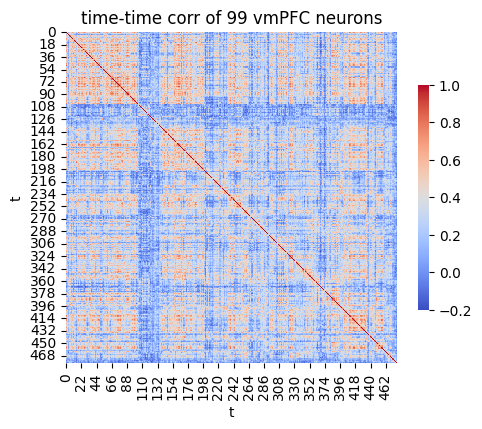

In [61]:
# print time-time corr of whole time
region = 'vmPFC' # '' for full mtx
cond_T_by_N = get_region_mtx(df_FRs, region).copy()

plt.figure(figsize=(5, 5))
sns.heatmap(np.corrcoef(cond_T_by_N), cmap='coolwarm', square=True, cbar_kws={'shrink': 0.5})
plt.title(f'time-time corr of {cond_T_by_N.shape[1]} {region} neurons')
plt.xlabel('t')
plt.ylabel('t')
plt.tight_layout()
plt.show()


## decoding

In [18]:
# gazeObj_df = pd.read_csv('../data/bin/P54CS_R1_gaze.csv', index_col=0)
# # would need rescaling
# gazeObj_df

In [19]:
# sen_sus_conds2 = sen_sus_conds[:-4]
# high_sen_low_sus = gazeObj_df[np.isin(sen_sus_conds2, [2])].copy()
# high_sen_high_sus = gazeObj_df[np.isin(sen_sus_conds2, [3])].copy()
# print(f'High Sensory, Low Suspense gaze objects: {len(high_sen_low_sus)}')
# print(f'High Sensory, High Suspense gaze objects: {len(high_sen_high_sus)}')

In [20]:
# # Count nonzero entries for each column
# low_sus_counts = high_sen_low_sus.sum()
# high_sus_counts = high_sen_high_sus.sum()

# # Plot
# fig, axs = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

# axs[0].bar(low_sus_counts.index, low_sus_counts.values, color='orange')
# axs[0].set_title('High Sensory, Low Suspense')
# axs[0].set_ylabel('Count')

# axs[1].bar(high_sus_counts.index, high_sus_counts.values, color='orange')
# axs[1].set_title('High Sensory, High Suspense')
# axs[1].set_ylabel('Count')
# axs[1].tick_params(axis='x', rotation=45)

# plt.tight_layout()
# plt.show()

In [21]:
# region = 'amygdala'
# cond_T_by_N = get_region_mtx(df_FRs, region)
# cond_T_by_N = cond_T_by_N[:-4].copy()
# print(f'T_by_N2 shape: {cond_T_by_N.shape}')
# print(f'High Sensory, Low Suspense gaze objects: {len(high_sen_low_sus)}')
# print(f'High Sensory, High Suspense gaze objects: {len(high_sen_high_sus)}')

In [22]:
# from sklearn.linear_model import LogisticRegression
# from sklearn.model_selection import cross_val_score
# import matplotlib.pyplot as plt
# import numpy as np

# # Assuming these exist
# # T_by_N2 = T_by_N[:-4].copy()
# sen_sus_conds2 = sen_sus_conds[:-4]
# protagonist_labels = gazeObj_df['protagonist'].values.astype(int)

# # Masks
# mask_low = sen_sus_conds2 == 2
# mask_high = sen_sus_conds2 == 3

# # Inputs and binary labels
# X_low = cond_T_by_N[mask_low]
# Y_low = protagonist_labels[mask_low]

# X_high = cond_T_by_N[mask_high]
# Y_high = protagonist_labels[mask_high]

# # Decode
# clf = LogisticRegression(max_iter=1000)
# acc_low = cross_val_score(clf, X_low, Y_low, cv=5).mean()
# acc_high = cross_val_score(clf, X_high, Y_high, cv=5).mean()

# # Plot
# plt.bar(['High Sen, Low Sus', 'High Sen, High Sus'], [acc_low, acc_high], color='orange')
# plt.ylabel('Decoding Accuracy')
# plt.title('Protagonist Gaze Decoding')
# plt.ylim(0, 1)
# plt.show()


In [23]:
# from sklearn.model_selection import cross_val_score
# from sklearn.linear_model import LogisticRegression
# import numpy as np

# # Get fold-wise scores
# clf = LogisticRegression(max_iter=1000)
# scores_low = cross_val_score(clf, X_low, Y_low, cv=5)
# scores_high = cross_val_score(clf, X_high, Y_high, cv=5)

# # Observed difference
# obs_diff = scores_high.mean() - scores_low.mean()

# # Permutation test
# n_perms = 10000
# combined = np.vstack([scores_low, scores_high])
# perm_diffs = []

# for _ in range(n_perms):
#     flip = np.random.rand(5) < 0.5
#     perm_low = np.where(flip, combined[0], combined[1])
#     perm_high = np.where(flip, combined[1], combined[0])
#     perm_diffs.append(perm_high.mean() - perm_low.mean())

# perm_diffs = np.array(perm_diffs)
# p_val = np.mean(np.abs(perm_diffs) >= np.abs(obs_diff))

# print(f'Observed difference: {obs_diff:.3f}')
# print(f'Permutation p-value: {p_val:.4f}')


### avg FR

dropping 275 neurs.
Retaining 207 neurs.
dropping 275 neurs.
Retaining 207 neurs.
dropping 275 neurs.
Retaining 207 neurs.
dropping 275 neurs.
Retaining 207 neurs.


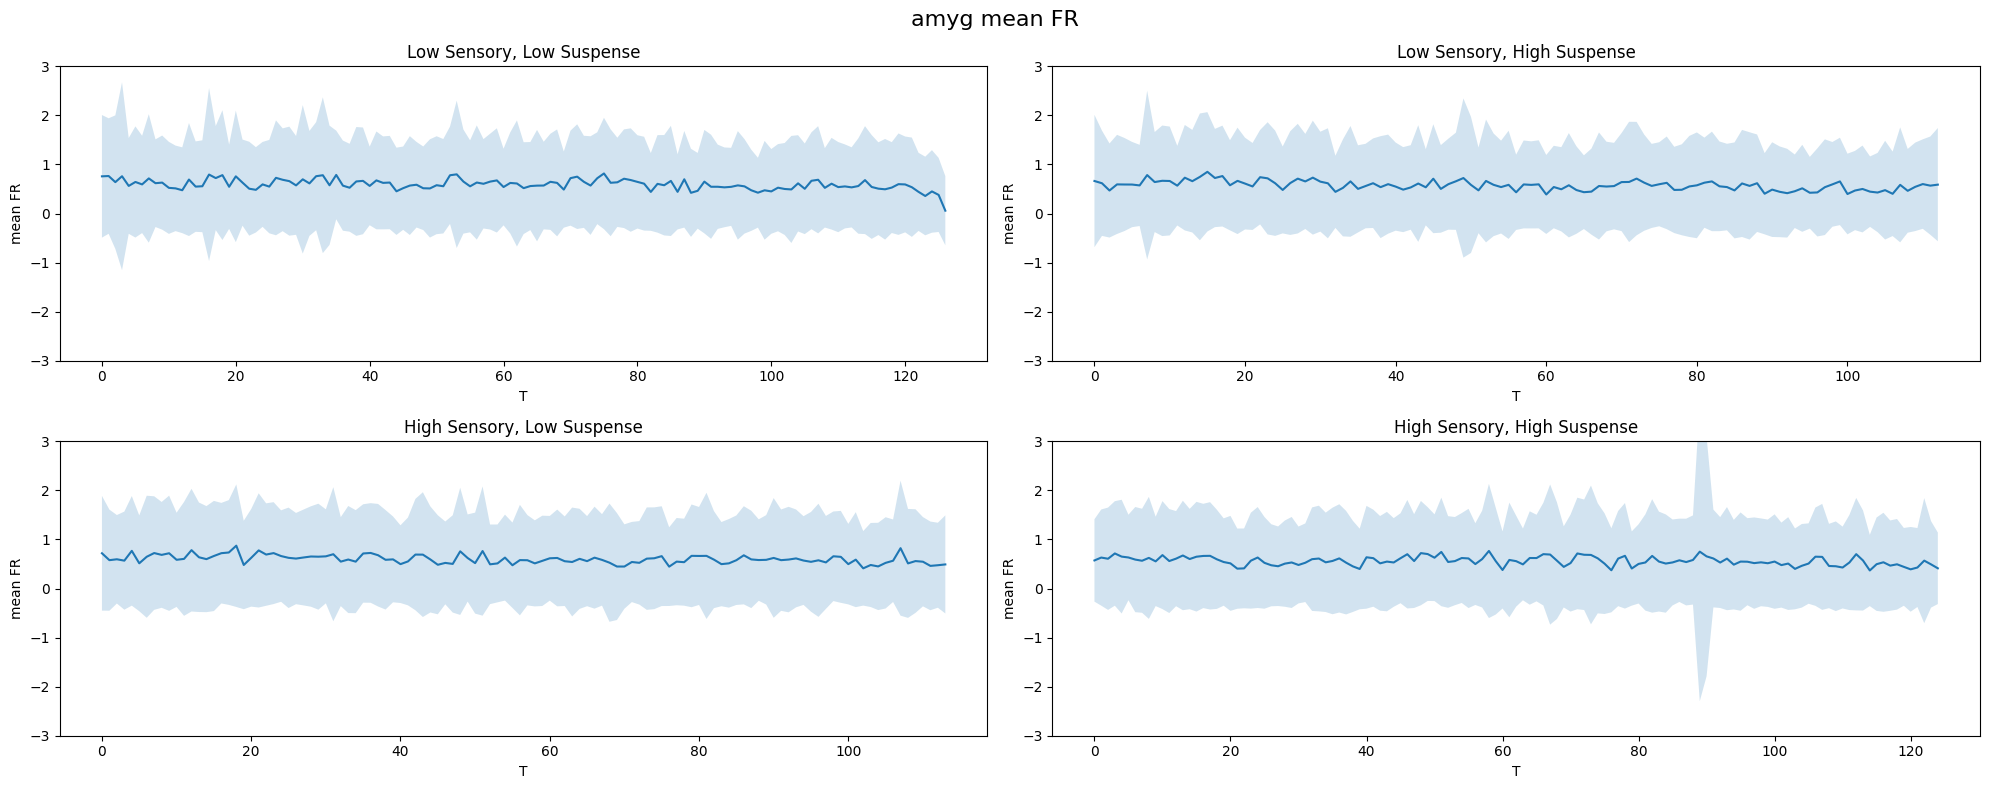

In [24]:
# plot
sen_sus_conds = get_conds(avg_sensory, avg_suspense)
fig, axs = plt.subplots(2, 2, figsize=(20, 8))
axs, ax = axs.flatten(), 0
plt_rng = 3
region = 'amyg'

for cond in range(4):

    if region == '': cond_N_by_T = N_by_T.copy() # full mtx
    else:            cond_N_by_T = get_region_mtx(df_FRs, region).copy().T # region mtx

    # index condition times
    cond_N_by_T = cond_N_by_T[:, sen_sus_conds == cond].copy()

    mean_FR = cond_N_by_T.mean(axis=0)
    std_FR  = cond_N_by_T.std(axis=0)
    t = np.arange(len(mean_FR))

    axs[ax].plot(t, mean_FR)
    axs[ax].fill_between(t, mean_FR - std_FR, mean_FR + std_FR, alpha=0.2)

    axs[ax].set(title=f'{cond_names[cond]}', xlabel='T', ylabel='mean FR', ylim=(-plt_rng, plt_rng))
    ax += 1

plt.suptitle(f'{region} mean FR', fontsize=16)
plt.tight_layout()
plt.show()
